### GLOFGuard – Model Training

This notebook trains and evaluates Logistic Regression and Random Forest models for glacial lake risk classification.

Because the classes are imbalanced, class-weight balancing is used during training. Missing historical growth values are median-imputed using the training data only.

### 1. Load Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, roc_auc_score)

df = pd.read_csv('../data/final/glofguard_training_data.csv')
print("Shape:", df.shape)

Shape: (8806, 13)


### 2. Select features

In [2]:
feature_cols = [
    'area',
    'temperature',
    'rainfall',
    'elevation',
    'distance_to_nearest_settlement_km',
    'annual_area_change_km2_per_year',
    'growth_data_available'
]

X = df[feature_cols].copy()
y = df['label']

print("Features:", feature_cols)
print("Class distribution:", y.value_counts().to_dict())
print("Class percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Features: ['area', 'temperature', 'rainfall', 'elevation', 'distance_to_nearest_settlement_km', 'annual_area_change_km2_per_year', 'growth_data_available']
Class distribution: {0: 8455, 1: 351}
Class percentages:
label
0    96.01
1     3.99
Name: proportion, dtype: float64


### 3. Train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (7044, 7) Test: (1762, 7)


### 4. Imputation

In [4]:
imputer = SimpleImputer(strategy='median')
X_train['annual_area_change_km2_per_year'] = imputer.fit_transform(
    X_train[['annual_area_change_km2_per_year']])
X_test['annual_area_change_km2_per_year'] = imputer.transform(
    X_test[['annual_area_change_km2_per_year']])

print("Missing in train after impute:", X_train.isna().sum().sum())
print("Missing in test after impute:", X_test.isna().sum().sum())

Missing in train after impute: 0
Missing in test after impute: 0


### 5. Scale features (needed for Logistic Regression)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

Logistic Regression provides an interpretable baseline model. Feature scaling is applied before training.

In [6]:
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_proba))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.83      0.91      1692
           1       0.17      0.84      0.29        70

    accuracy                           0.83      1762
   macro avg       0.58      0.84      0.60      1762
weighted avg       0.96      0.83      0.88      1762

ROC-AUC: 0.8986744343127322


## Random Forest

Random Forest is trained to capture nonlinear relationships between lake characteristics and risk.

In [7]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1692
           1       0.81      0.83      0.82        70

    accuracy                           0.99      1762
   macro avg       0.90      0.91      0.90      1762
weighted avg       0.99      0.99      0.99      1762

ROC-AUC: 0.9876519756838906


## Feature Importance

Random Forest feature importance is examined to understand which input variables contribute most to the model.

In [8]:
importances = pd.Series(rf_model.feature_importances_, 
                        index=feature_cols).sort_values(ascending=False)
print(importances)

elevation                            0.335501
distance_to_nearest_settlement_km    0.234366
rainfall                             0.185987
temperature                          0.143542
area                                 0.068558
annual_area_change_km2_per_year      0.019132
growth_data_available                0.012914
dtype: float64


### Class distribution 

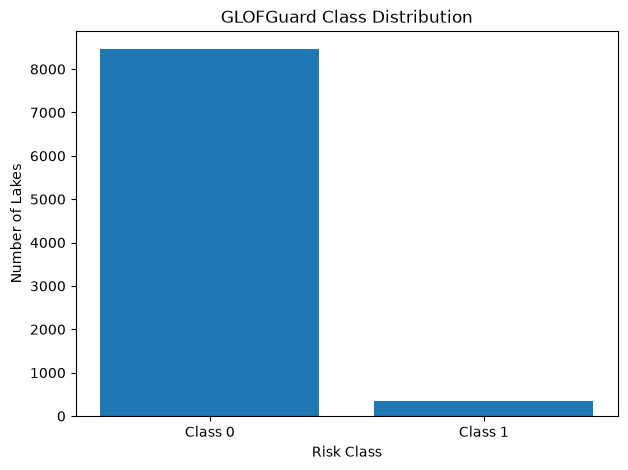

In [9]:
import matplotlib.pyplot as plt

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(['Class 0', 'Class 1'], class_counts.values)
plt.title('GLOFGuard Class Distribution')
plt.xlabel('Risk Class')
plt.ylabel('Number of Lakes')
plt.show()

### Confusion matrices

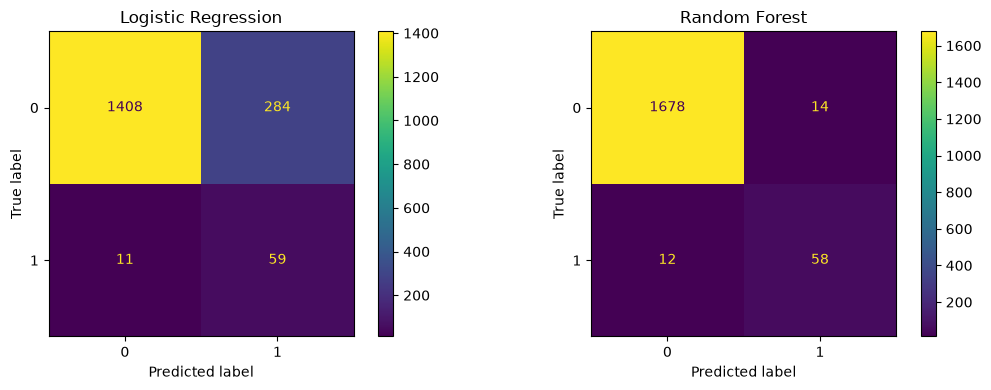

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, log_preds, ax=axes[0]
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, ax=axes[1]
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

### Model performance comparison

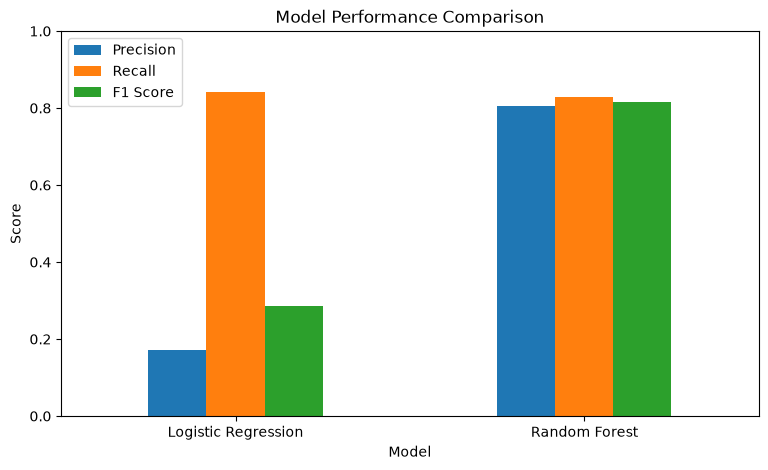

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.172012,0.842857,0.285714
1,Random Forest,0.805556,0.828571,0.816901


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, log_preds),
        precision_score(y_test, rf_preds)
    ],
    'Recall': [
        recall_score(y_test, log_preds),
        recall_score(y_test, rf_preds)
    ],
    'F1 Score': [
        f1_score(y_test, log_preds),
        f1_score(y_test, rf_preds)
    ]
})

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

comparison

### Feature importance

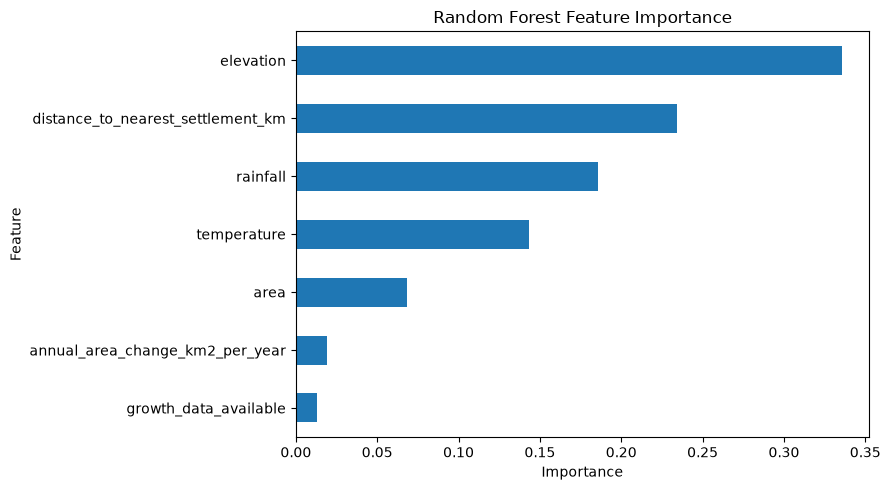

In [12]:
plt.figure(figsize=(9, 5))

importances.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## Save trained model and preprocessing objects

The trained Random Forest model and preprocessing information are saved for use in the Streamlit application.

In [14]:
import joblib

joblib.dump(rf_model, '../artifacts/rf_model.joblib')
joblib.dump(scaler, '../artifacts/scaler.joblib')
joblib.dump(imputer, '../artifacts/imputer.joblib')
joblib.dump(feature_cols, '../artifacts/feature_cols.joblib')

print("Saved: rf_model, scaler, imputer, feature_cols")

Saved: rf_model, scaler, imputer, feature_cols
